# CTC image-encoder — diagnostic notebook

Interactive companion to `test_model.py`. It loads a trained `ImageEncoderCTC`
checkpoint (`.safetensors`) and runs it over a HuggingFace dataset of Telugu line
images, following the investigation playbook:

1. **Per-sample predictions** next to ground truth (+ CER) — read 30–50 of these.
2. **CER vs length** and the **per-sample CER histogram** — uniform vs bimodal.
3. **Breakdowns** by `font`, `text_source`, `language`, `is_fragment`, `cut_type`,
   `font_size`, `text_len` — a broken subset (usually a font) falls out here.
4. Optional **degraded pass** (augmented on the fly) for the clean-vs-degraded gap.

All logic lives in `test_model.py`; this notebook just orchestrates + renders.

## Setup

In [ ]:
%matplotlib inline
import os, sys

# Make the repo root importable regardless of launch dir.
_cand = os.path.abspath('')
for _ in range(6):
    if os.path.isdir(os.path.join(_cand, 'src', 'telugu_ocr')):
        break
    _cand = os.path.dirname(_cand)
ROOT = _cand
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import torch
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import scripts.eval.image_encoder as tm
print('loaded eval module from', tm.__file__)

## Config — edit me

In [24]:
MODEL_PATH = os.path.join(ROOT, 'models/image_encoder/ctc_encoder/ctc-encoder/checkpoint-152000/model.safetensors')  # <- your downloaded .safetensors
DATASET_NAME = 'harsha-desaraju/line-test-image-test'                  # HF id or local path
DATASET_SPLIT = 'unseen_fonts'
VOCAB_FILE = os.path.join(ROOT, 'src/telugu_ocr/tokenizer/assets/telugu-vocab.json')
IMAGE_COLUMN = 'image'


NUM_SAMPLES = 1000  # (separate) sample size for the group breakdowns
SEED = 42
BATCH_SIZE = 16
NUM_HEADS = 8                 # must match training (not inferable from weights)
DEVICE = 'mps' if torch.backends.mps.is_available() else 'cpu'
RUN_AUGMENTED = False         # True -> clean-vs-degraded gap (needs `pip install augraphy`)
COLS_TO_REMOVE = ['cut_type', 'is_fragment']
print('device:', DEVICE)

device: mps


## Load tokenizer + model
A tokenizer-vs-model vocab mismatch (warning below) is the signature of a
renderer/CTC-label mismatch — fix the vocab file before trusting any CER.

In [25]:
tokenizer = tm.TeluguGraphemeTokenizer(vocab_file=VOCAB_FILE)
print('tokenizer vocab size:', len(tokenizer))
model, cfg = tm.load_model(MODEL_PATH, NUM_HEADS, DEVICE)
if len(tokenizer) != cfg.vocab_size:
    print(f'[WARN] tokenizer vocab ({len(tokenizer)}) != model classes-1 ({cfg.vocab_size}); decoding will be wrong.')

tokenizer vocab size: 2048
[load] layers=10 d=384 heads=8 mlp=1536 max_frames=128 classes=2049 (blank=2048)


## Load dataset + draw a random sample

In [30]:
from datasets import load_dataset
ds = load_dataset(DATASET_NAME, split=DATASET_SPLIT)
ds = ds.remove_columns(column_names=COLS_TO_REMOVE)


# Filter the dataset to have only the random text samples
ds = ds.filter(lambda x: x['text_source']=="natural")



print(len(ds), 'rows; columns:', ds.column_names)

n_eval = min(NUM_SAMPLES, len(ds))
gen = torch.Generator().manual_seed(SEED)
idxs = torch.randperm(len(ds), generator=gen)[:n_eval].tolist()
rows = [ds[i] for i in idxs]
print('evaluating', n_eval, 'random samples')

Filter: 100%|██████████| 5000/5000 [00:00<00:00, 5684.82 examples/s]


4339 rows; columns: ['language', 'text', 'text_len', 'text_source', 'image', 'font', 'font_size']
evaluating 1000 random samples


## Run inference

In [31]:
results = tm.run_inference(model, cfg, tokenizer, rows, IMAGE_COLUMN, DEVICE, BATCH_SIZE)
print(f'Sample corpus CER ({NUM_SAMPLES})     : %.2f%%' % (tm.corpus_cer(results) * 100))

Sample corpus CER (1000)     : 3.40%


## 1. Per-sample predictions (random set)

`ref` vs `pred` with CER%, length, and the **line image** rendered inline (worst-CER first, so hard/degraded images surface at the top). Scan for systematic missing vowel-signs/conjuncts (label/tokenizer issue) vs look-alike confusions on degraded images (difficulty).

image,ref,CER%
,ప్ఫై,100.00
,",",100.00
,బిజి,100.00
,మరియు ఛాయాచిత్రాలు ఉత్పత్తి; - పరికరం లో మీడియా ఫైళ్లు అందుకున్న శిల్పాలను సంరక్షించేందుకు తొలగించడానికి; - పూర్తి HD 4K బదులుగా వీడియో రికార్డింగ్ ఉత్పత్తి; - ఉపయోగించని భాషా వ్యవస్థల తొలగించడానికి; - iTunes,52.07
,తర,50.00
,లాబ,50.00
,శ.,50.00
,విద్యయా విద్యామాత్మసాక్షాత్కారరూపా సత్రామయిష్యసీతి యోజనా । శ్రూయతే హి సకర్షణవి 1 'ప్రవోధోదయం చ పురుపే సమ్యగ్వివేకేన సహ । తతో మత్సకాశమాగమిష్యసి ' ఇతి పాఠ . । ఉపనిషత్ - యదాదిశతి దేవీ । ( ఇతి,45.69
,speak,40.00
,మరవకుండా ప్రవాస తెలంగాణవాసులు పర్వదినాలను ఘనంగా నిర్వహిస్తున్నారు. తెలంగాణలో అతిపెద్ద పండుగా అయిన బతుకమ్మ వేడుకల్ని యూనైటీడ్ అరబ్ ఎమిరెట్స్(యూ. ఏ. ఇ)లో ఎమిరెట్స్ తెలంగాణ సాంస్కృతిక సంఘం(ఇ. టి.,38.94

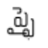
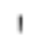
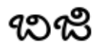
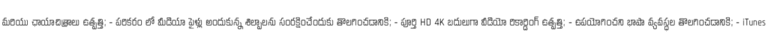
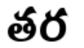
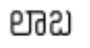
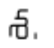
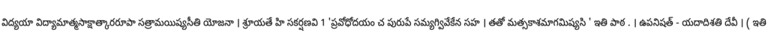
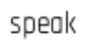
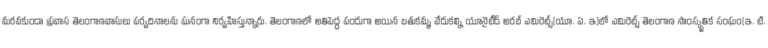
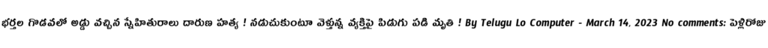
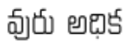
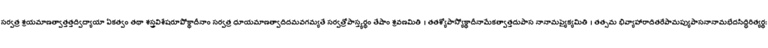
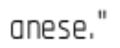
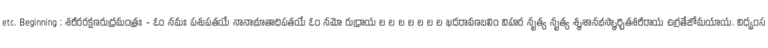

In [32]:
# Poor-CER-first, with the line image rendered inline (limit=None shows all).
tm.render_samples(results, sort_by='CER%', ascending=False, limit=15,
                  meta_cols=('text_len'), content_cols=('ref', 'text_len', 'CER%'))

# Plain table without images (sortable):
#   tm.results_dataframe(results)[['text_source', 'ref', 'pred', 'CER%']]

## Random-sample CER **with lengths**
The table (sorted by length) and the scatters below. CER rising with length →
an `input_lengths` / truncation / bucketing bug; flat → length isn't the driver.

,idx,graphemes,frames,CER%
0,454,1,8,100.00
1,393,1,7,100.00
2,34,2,17,100.00
3,130,121,128,52.07
4,835,2,14,50.00
...,...,...,...,...
995,401,12,60,0.00
996,402,81,128,0.00
997,403,27,77,0.00
998,404,15,59,0.00


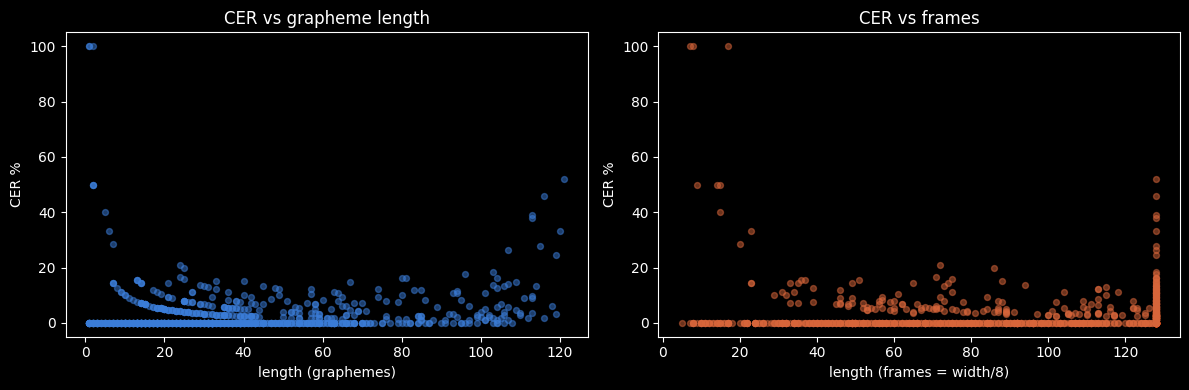

In [33]:
# CER alongside each sample's length (graphemes and frames), over `results`.
len_df = (tm.results_dataframe(results)[['idx', 'graphemes', 'frames', 'CER%']]
          .sort_values('CER%', ascending=False).reset_index(drop=True))
display(len_df)

g = [r['ref_len'] for r in results]
f = [r['frames'] for r in results]
c = [min(r['cer'], 1.0) * 100 for r in results]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(g, c, s=18, alpha=0.5, color='#3b7dd8')
ax[0].set_xlabel('length (graphemes)'); ax[0].set_ylabel('CER %'); ax[0].set_title('CER vs grapheme length')
ax[1].scatter(f, c, s=18, alpha=0.5, color='#d8663b')
ax[1].set_xlabel('length (frames = width/8)'); ax[1].set_ylabel('CER %'); ax[1].set_title('CER vs frames')
plt.tight_layout(); plt.show()

## 2. Per-sample CER histogram
Uniform mediocrity → global cause (labels/difficulty/capacity). Bimodal (a 0%
cluster + an 80–100% cluster) → a broken subset; check the per-font table.


PER-SAMPLE CER HISTOGRAM
corpus CER: 70.77%   mean: 49.65%   median: 48.15%   n=636
    0-  5% |   129 ########################################
    5- 10% |    49 ###############
   10- 15% |    43 #############
   15- 20% |    32 ##########
   20- 25% |    20 ######
   25- 30% |    17 #####
   30- 35% |    10 ###
   35- 40% |     5 ##
   40- 45% |     7 ##
   45- 50% |     7 ##
   50- 55% |    15 #####
   55- 60% |     6 ##
   60- 65% |     7 ##
   65- 70% |     7 ##
   70- 75% |     4 #
   75- 80% |    14 ####
   80- 85% |    23 #######
   85- 90% |    41 #############
   90- 95% |    85 ##########################
   95-100% |   115 ####################################
  -> BIMODAL: 20% near-perfect, 41% near-broken — check the per-font table for a broken subset.


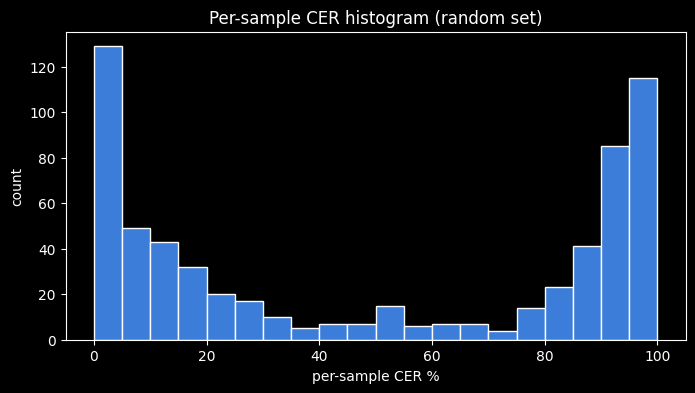

In [18]:
tm.print_histogram(results)
cers = [min(r['cer'], 1.0) * 100 for r in results]
plt.figure(figsize=(8, 4))
plt.hist(cers, bins=20, range=(0, 100), color='#3b7dd8', edgecolor='white')
plt.xlabel('per-sample CER %'); plt.ylabel('count')
plt.title('Per-sample CER histogram (random set)'); plt.show()

## 3. Breakdowns (over the full evaluated set)

In [19]:
for col in ['font', 'text_source', 'language', 'font_size']:
    print(col)
    display(tm.cer_table(results, col))
display(tm.cer_table(results, 'text_len', bucket_fn=tm._bucket_int([10, 20, 40, 80])))

font


,font,n,corpus_CER%,mean_CER%
0,AnekTelugu_Condensed-Regular,18,95.26,95.72
1,Akshar,13,84.08,77.18
2,ravi-prakash,36,82.53,63.24
3,Manu_Bold,17,81.14,57.55
4,hind-guntur,28,74.97,60.06
5,AkayaTelivigala-Regular,25,74.41,52.22
6,Suravaram-Regular,27,74.27,50.90
7,sree-krushnadevaraya,28,73.57,53.32
8,lakki-reddy,21,73.55,51.96
9,Amruta-Bold,16,73.23,56.50


text_source


,text_source,n,corpus_CER%,mean_CER%
0,random,636,70.77,49.65


language


,language,n,corpus_CER%,mean_CER%
0,telugu,527,72.06,51.44
1,sanskrit,109,64.67,40.98


font_size


,font_size,n,corpus_CER%,mean_CER%
0,40,103,75.80,55.07
1,36,100,72.98,53.41
2,34,95,72.56,51.22
3,32,117,69.57,47.60
4,30,117,69.56,50.02
5,38,104,63.00,41.12


,text_len,n,corpus_CER%,mean_CER%
0,41-80,118,96.11,96.11
1,>80,53,88.40,88.67
2,21-40,235,56.46,51.12
3,0-10,77,17.84,16.03
4,11-20,153,15.18,14.97


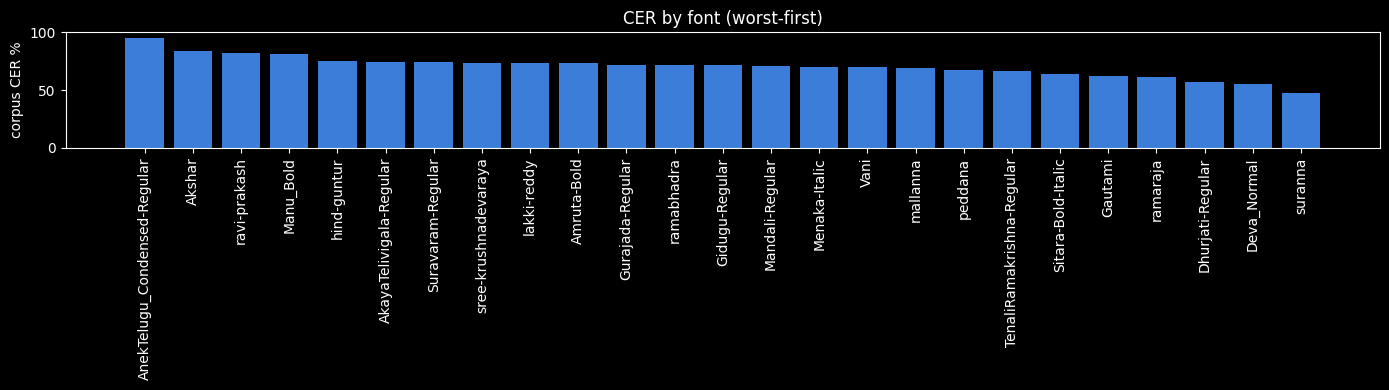

In [20]:
st = tm.cer_stats(results, 'font')
names = [str(s['group']) for s in st]
vals = [s['corpus_cer'] * 100 for s in st]
plt.figure(figsize=(min(14, 0.5 * len(names) + 3), 4))
plt.bar(range(len(names)), vals, color='#3b7dd8')
plt.xticks(range(len(names)), names, rotation=90)
plt.ylabel('corpus CER %'); plt.title('CER by font (worst-first)')
plt.tight_layout(); plt.show()

## 4. Optional: degraded (augmented) pass
Set `RUN_AUGMENTED = True` in the config cell and `pip install augraphy`. If clean
CER is low (~2–3%) but degraded is high (~35%), augmentation is too aggressive for
the budget — soften the top-end severities / extend curriculum, then resume.

In [ ]:
if RUN_AUGMENTED:
    from src.telugu_ocr.training.loops.ctc import make_weighted_augmenter, set_seed
    set_seed(SEED)
    aug = tm.run_inference(model, cfg, tokenizer, rows, IMAGE_COLUMN, DEVICE, BATCH_SIZE,
                           augment_fn=make_weighted_augmenter())
    clean_c, deg_c = tm.corpus_cer(results), tm.corpus_cer(aug)
    print('clean corpus CER   : %.2f%%' % (clean_c * 100))
    print('degraded corpus CER: %.2f%%  (gap %+.2f pts)' % (deg_c * 100, (deg_c - clean_c) * 100))
    tm.print_histogram(aug[:len(results)])
else:
    print('RUN_AUGMENTED=False — set True + install augraphy for the clean-vs-degraded gap')